# Table of Contents

1. [Load Data](#load-data)
2. [Data Cleaning and Feature engineering](#data-cleaning-and-feature-engineering)
3. [Dimentionality Reduction](#dimentionality-reduction)
4. [KMeans Clustering](#kmeans-clustering)
5. [Result Analysis & Visualizations](#result-analysis--visualizations)
6. [Refine Business Dominant Cluster1](#refine-business-dominant-cluster1)
7. [Subset Data Preprocessing](#subset-data-preprocessing)
8. [Visualizations for Refined Cluster1 Subclusters](#visualizations-for-refined-cluster1-subclusters)

## Load Data

In [1]:
import pandas as pd

csv_path = "../Clustering/clustering_Cleaned.csv"
df = pd.read_csv(csv_path)

df.head()

,customer_id,kyc_type,province,city,industry_code,occupation_code,sales_cents,account_age,birth_business_age,total_transaction_count,...,abm_transaction_count,abm_cash_count,abm_non_cash_count,abm_cash_to_non_cash_ratio,Debit_Amount_Total,Credit_Amount_Total,Averagetime_between_alltransaction,std_time_between_transactions,median_time_between_transactions,pct_transactions_top10_busiest_days
0,SYNID0108229423,individual,other,other,NaN,13100,NaN,29.62,68.65,114,...,2.0,1.0,1.0,1.0,803387.0,12299.0,0.787278,0.712698,0.607888,20.175439
1,SYNID0102628368,individual,ON,WINDSOR,NaN,41101,NaN,8.87,57.61,8,...,NaN,NaN,NaN,NaN,146360.0,228053.0,12.878022,8.829264,12.000000,12.500000
2,SYNID0107013748,individual,BC,SURREY,NaN,42202,NaN,3.83,26.42,149,...,7.0,6.0,1.0,6.0,6381165.4,2539715.0,0.617069,0.709136,0.377025,20.805369
3,SYNID0109706496,individual,ON,BRAMPTON,NaN,10019,NaN,8.02,58.92,3,...,NaN,NaN,NaN,NaN,108576.0,3359.0,12.672078,13.335715,3.242303,33.333333
4,SYNID0100925078,individual,ON,TORONTO,NaN,OTHER,NaN,32.49,66.61,39,...,NaN,NaN,NaN,NaN,1320470.0,1677447.0,2.357771,2.720995,1.350775,23.076923


In [2]:
# Drop specified columns
cols_to_drop = ['card_transaction_count', 'abm_transaction_count', 'Debit_Amount_Total', 'Credit_Amount_Total']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No specified columns found to drop")
df.isna().sum()

Dropped columns: ['card_transaction_count', 'abm_transaction_count', 'Debit_Amount_Total', 'Credit_Amount_Total']


customer_id                                 0
kyc_type                                    0
province                                    0
city                                        0
industry_code                           53119
occupation_code                          8398
sales_cents                             53099
account_age                              4779
birth_business_age                       3936
total_transaction_count                     0
transaction_count_ABM                       0
transaction_count_Card                      0
transaction_count_Cheque                    0
transaction_count_EFT                       0
transaction_count_EMT                       0
transaction_count_Western Union             0
transaction_count_Wire                      0
debit_transaction_count                   544
debit_transaction_amount                  544
credit_transaction_count                 2080
credit_transaction_amount                2080
average_debit_transaction_amount  

## Data Cleaning and Feature engineering

In [3]:
# Merge industry_code and occupation_code into economic_role
import numpy as np

# 1) Check if both industry_code and occupation_code are null
both_null_mask = df["industry_code"].isna() & df["occupation_code"].isna()

# 2) Create merged economic role column
df["economic_role"] = np.where(
    df["kyc_type"].str.lower() == "business",
    "BUSINESS_" + df["industry_code"].astype(str),
    "INDIVIDUAL_" + df["occupation_code"].astype(str)
)

# 3) Set "Both_N/A" for rows where both codes are null
df.loc[both_null_mask, "economic_role"] = "Both_N/A"

# 4) Clean placeholder / invalid values (keep Both_N/A)
df["economic_role"] = df["economic_role"].replace(
    {
        "BUSINESS_nan": np.nan,
        "INDIVIDUAL_nan": np.nan,
        "BUSINESS_N/A": np.nan,
        "INDIVIDUAL_N/A": np.nan,
        "BUSINESS_None": np.nan,
        "INDIVIDUAL_None": np.nan,
    }
)

# 5) Convert to categorical dtype (for FAMD)
df["economic_role"] = df["economic_role"].astype("category")

# 6) Drop original columns after merge
df = df.drop(columns=["industry_code", "occupation_code"])

# 7) Quick sanity checks (optional but recommended)
print("economic_role nunique:", df["economic_role"].nunique())
print(df["economic_role"].value_counts().head(10))

economic_role nunique: 272
economic_role
INDIVIDUAL_OTHER            10683
INDIVIDUAL_RETIRED          10243
INDIVIDUAL_STUDENT           6149
INDIVIDUAL_UNEMPLOYED        4952
INDIVIDUAL_SELF_EMPLOYED     4492
BUSINESS_Other               1528
INDIVIDUAL_10019             1504
INDIVIDUAL_60010              709
INDIVIDUAL_14100              687
BUSINESS_7215                 661
Name: count, dtype: int64


In [4]:
# Replace economic_role values that appear less than 50 times with BUSINESS_Other or INDIVIDUAL_OTHER based on kyc_type
if 'economic_role' in df.columns:
    # Count frequency of each economic_role
    economic_role_counts = df['economic_role'].value_counts()
    
    # Find economic_role values that appear less than 50 times (excluding NaN)
    rare_economic_roles = economic_role_counts[economic_role_counts < 50].index.tolist()
    
    print(f"Found {len(rare_economic_roles)} economic_role values appearing less than 50 times")
    
    # Create mask for rows with rare economic_role values
    rare_mask = df['economic_role'].isin(rare_economic_roles)
    print(f"Total rows to be changed: {rare_mask.sum()}")
    
    # Replace rare economic_role values based on kyc_type
    df.loc[rare_mask & (df['kyc_type'].str.lower() == 'business'), 'economic_role'] = 'BUSINESS_Other'
    df.loc[rare_mask & (df['kyc_type'].str.lower() != 'business'), 'economic_role'] = 'INDIVIDUAL_OTHER'
    
    # Convert back to category after replacement
    df['economic_role'] = df['economic_role'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated economic_role distribution:")
    print(df['economic_role'].value_counts().head(10))
else:
    print("Column 'economic_role' not found in dataframe")

Found 150 economic_role values appearing less than 50 times
Total rows to be changed: 2910

Updated economic_role distribution:
economic_role
INDIVIDUAL_OTHER            11173
INDIVIDUAL_RETIRED          10243
INDIVIDUAL_STUDENT           6149
INDIVIDUAL_UNEMPLOYED        4952
INDIVIDUAL_SELF_EMPLOYED     4492
BUSINESS_Other               3948
INDIVIDUAL_10019             1504
INDIVIDUAL_60010              709
INDIVIDUAL_14100              687
BUSINESS_7215                 661
Name: count, dtype: int64


In [5]:
# 2. account_age and birth_business_age: fill nulls with median
# Fill with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())
# 3. Engineer credit_share feature and handle transaction count columns
# First, fill nulls in transaction count columns to calculate credit_share
if 'debit_transaction_count' in df.columns:
    df['debit_transaction_count'] = df['debit_transaction_count'].fillna(0)
if 'credit_transaction_count' in df.columns:
    df['credit_transaction_count'] = df['credit_transaction_count'].fillna(0)
if 'total_transaction_count' in df.columns:
    df['total_transaction_count'] = df['total_transaction_count'].fillna(0)

# Engineer credit_share: credit_transaction_count / total_transaction_count
# Set to 0 when total_transaction_count == 0
if 'credit_transaction_count' in df.columns and 'total_transaction_count' in df.columns:
    df['credit_share'] = np.where(
        df['total_transaction_count'] > 0,
        df['credit_transaction_count'] / df['total_transaction_count'],
        0
    )
    print("Engineered credit_share feature")
    
    # Drop redundant transaction count columns
    cols_to_drop = []
    if 'debit_transaction_count' in df.columns:
        cols_to_drop.append('debit_transaction_count')
    if 'credit_transaction_count' in df.columns:
        cols_to_drop.append('credit_transaction_count')
    
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        print(f"Dropped redundant columns: {cols_to_drop}")
else:
    print("Warning: credit_transaction_count or total_transaction_count not found")

# Fill remaining debit and credit amount columns nulls to 0
debit_credit_amount_cols = [
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_amount_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill the three new columns - Debit_Amount_Total and Credit_Amount_Total with 0
# Fill Debit_Amount_Total and Credit_Amount_Total with 0
for col in ['Debit_Amount_Total', 'Credit_Amount_Total']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"Filled null values in '{col}' with 0")
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

# Fill Averagetime_between_transaction_day with median (not 0)
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill the three new time-based columns
# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")

Engineered credit_share feature
Dropped redundant columns: ['debit_transaction_count', 'credit_transaction_count']
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 1.4220
Filled null values in 'std_time_between_transactions' with median: 1.4638
Filled null values in 'median_time_between_transactions' with median: 0.8881
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [6]:
# 4. Engineer ABM_cash_weight feature and handle ABM columns
# Engineer ABM_cash_weight before dropping columns
if 'abm_cash_count' in df.columns and 'abm_non_cash_count' in df.columns:
    # Calculate denominator
    denominator = df['abm_cash_count'].fillna(0) + df['abm_non_cash_count'].fillna(0)
    
    # Calculate ABM_cash_weight: abm_cash_count / (abm_cash_count + abm_non_cash_count)
    # If denominator is 0 or both are missing, set to 0
    df['ABM_cash_weight'] = np.where(
        denominator > 0,
        df['abm_cash_count'].fillna(0) / denominator,
        0
    )
    
    # Drop the sparse ABM sub-count columns
    df = df.drop(columns=['abm_cash_count', 'abm_non_cash_count'])
    print("Engineered ABM_cash_weight and dropped abm_cash_count, abm_non_cash_count")
else:
    print("Warning: abm_cash_count or abm_non_cash_count not found")

# Drop abm_cash_to_non_cash_ratio if it exists
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped abm_cash_to_non_cash_ratio")

# Drop transaction_count_Western Union and transaction_count_Wire columns
cols_to_drop = []
if 'transaction_count_Western Union' in df.columns:
    cols_to_drop.append('transaction_count_Western Union')
if 'transaction_count_Wire' in df.columns:
    cols_to_drop.append('transaction_count_Wire')

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")

# Fill nulls in columns with prefix 'card_' or 'abm_' to 0
# Keep abm_transaction_count as-is (fill nulls to 0)
card_abm_cols = [col for col in df.columns if col.startswith('card_') or col.startswith('abm_')]
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_ecommerce_to_nonecommerce_ratio':
        df[col] = df[col].fillna(df[col].median())
    else:
        # Fill abm_transaction_count and other ABM columns with 0
        df[col] = df[col].fillna(0)

Engineered ABM_cash_weight and dropped abm_cash_count, abm_non_cash_count
Dropped abm_cash_to_non_cash_ratio
Dropped columns: ['transaction_count_Western Union', 'transaction_count_Wire']


In [7]:
# 6. Replace MCC codes in card_top_mcc that appear less than 100 times with "other"
if 'card_top_mcc' in df.columns:
    # Count frequency of each MCC code
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 100 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 100 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(10))
else:
    print("Column 'card_top_mcc' not found in dataframe")

Found 86 MCC codes appearing less than 100 times
Total rows to be changed: 1258

Updated card_top_mcc distribution:
card_top_mcc
5814     22666
N/A      12184
5411     11881
0         3194
other     1843
5310      1786
5812      1565
5541      1467
4816       763
5542       734
Name: count, dtype: int64


In [8]:
# 7. Replace cities that appear less than 100 times with "other"
if 'city' in df.columns:
    # Count frequency of each city
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 100 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 100 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(10))
else:
    print("Column 'city' not found in dataframe")

Found 80 cities appearing less than 100 times
Total rows to be changed: 3976

Updated city distribution:
city
other          24517
TORONTO         3792
BRAMPTON        2275
CALGARY         2141
EDMONTON        1933
WINNIPEG        1399
SCARBOROUGH     1382
MISSISSAUGA     1359
SURREY          1200
VANCOUVER       1170
Name: count, dtype: int64


In [9]:
# Check for and handle infinite values before FAMD
import numpy as np

# Replace infinite values with NaN, then fill with 0 for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if np.isinf(df[col]).any():
        inf_count = np.isinf(df[col]).sum()
        print(f"Warning: Found {inf_count} infinite values in '{col}', replacing with 0")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# Check for any remaining NaN values in numeric columns
nan_counts = df[numeric_cols].isna().sum()
if nan_counts.sum() > 0:
    print(f"\nWarning: Found NaN values in numeric columns:")
    print(nan_counts[nan_counts > 0])
    df[numeric_cols] = df[numeric_cols].fillna(0)

print("✓ All infinite and NaN values handled")


sales_cents    53099
dtype: int64
✓ All infinite and NaN values handled


In [10]:
# 5. Remove Sales_cents column
if 'sales_cents' in df.columns:
    df = df.drop(columns=['sales_cents'])
    df = df.drop(columns=['customer_id'])
    df = df.drop(columns=['card_second_mcc'])

In [11]:
# Count number of categories for each categorical column after small category removal
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Create summary dataframe
category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY:")
print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Average categories per column: {category_df['Number of Categories'].mean():.1f}")
print(f"Max categories: {category_df['Number of Categories'].max()} ({category_df.loc[category_df['Number of Categories'].idxmax(), 'Column']})")
print(f"Min categories: {category_df['Number of Categories'].min()} ({category_df.loc[category_df['Number of Categories'].idxmin(), 'Column']})")

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 5 categorical columns:

       Column  Number of Categories  Null Count    Dtype
economic_role                   122           0 category
         city                    90           0   object
 card_top_mcc                    22           0   object
     province                    12           0   object
     kyc_type                     2           0   object

SUMMARY:
Total categorical columns: 5
Average categories per column: 49.6
Max categories: 122 (economic_role)
Min categories: 2 (kyc_type)


In [12]:

print("=" * 80)
print("DATA TYPE CLEANUP")

# 2. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# 3. Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]
print(f"\nConverting {len(non_categorical_cols)} non-categorical columns to float64...")

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"✓ Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print("\n" + "=" * 80)
print("FINAL DATA TYPE SUMMARY:")
print("=" * 80)
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")
print(f"\nUnique dtypes: {df.dtypes.value_counts().to_dict()}")

DATA TYPE CLEANUP

Categorical columns (will be preserved): ['kyc_type', 'province', 'city', 'card_top_mcc', 'economic_role']

Converting 26 non-categorical columns to float64...
✓ Converted 26 columns to float64

FINAL DATA TYPE SUMMARY:
Total columns: 31
Categorical columns: 5
Float64 columns: 26

Unique dtypes: {dtype('float64'): 26, dtype('O'): 4, CategoricalDtype(categories=['BUSINESS_0112', 'BUSINESS_0119', 'BUSINESS_0139',
                  'BUSINESS_0141', 'BUSINESS_0171', 'BUSINESS_0211',
                  'BUSINESS_0219', 'BUSINESS_0311', 'BUSINESS_0411',
                  'BUSINESS_0511',
                  ...
                  'INDIVIDUAL_90010', 'INDIVIDUAL_920', 'INDIVIDUAL_9201',
                  'INDIVIDUAL_942', 'INDIVIDUAL_95109', 'INDIVIDUAL_OTHER',
                  'INDIVIDUAL_RETIRED', 'INDIVIDUAL_SELF_EMPLOYED',
                  'INDIVIDUAL_STUDENT', 'INDIVIDUAL_UNEMPLOYED'],
, ordered=False, categories_dtype=object): 1}


## Dimentionality Reduction

In [13]:
import prince

df_famd = df.copy()

# Add customer_id back before saving to VersionB_BeforeFAMD.csv (preserving order, no sorting)
if 'customer_id' not in df_famd.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    
    # Use index alignment to preserve order (no sorting)
    if len(df_original) == len(df_famd):
        df_original_reset = df_original.reset_index(drop=True)
        df_famd_reset = df_famd.reset_index(drop=True)
        df_famd['customer_id'] = df_original_reset['customer_id'].values
        print("customer_id restored from original dataset (order preserved)")
    else:
        raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df_famd)}")

# Reorder columns to put customer_id first (preserving row order)
if 'customer_id' in df_famd.columns:
    cols = ['customer_id'] + [col for col in df_famd.columns if col != 'customer_id']
    df_famd = df_famd[cols]
before_famd = "../Clustering/VersionB_BeforeFAMD.csv"
df_famd.to_csv(before_famd, index=False)
print(f"Saved to {before_famd}")
# Remove customer_id after saving (preserving order)
if 'customer_id' in df_famd.columns:
    df_famd = df_famd.drop(columns=['customer_id'])
    print("customer_id removed after saving (order preserved)")

print(f"Fitting FAMD on full dataset with {len(df_famd)} rows...")

famd = prince.FAMD(
    n_components=10,   # <-- for clustering
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)

famd = famd.fit(df_famd)

print("FAMD fitting completed!")
famd.eigenvalues_summary

customer_id restored from original dataset (order preserved)
Saved to ../Clustering/VersionB_BeforeFAMD.csv
customer_id removed after saving (order preserved)
Fitting FAMD on full dataset with 61410 rows...
FAMD fitting completed!


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,10.149,1.60%,1.60%
1,5.011,0.79%,2.39%
2,4.819,0.76%,3.15%
3,4.747,0.75%,3.90%
4,4.672,0.74%,4.64%
5,4.559,0.72%,5.36%
6,4.473,0.71%,6.07%
7,4.401,0.69%,6.76%
8,4.231,0.67%,7.43%


In [14]:
famd.column_contributions_.style.format('{:.2%}')

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
account_age,0.11%,1.47%,1.01%,0.05%,0.00%,0.17%,0.00%,0.07%,0.24%,0.20%
birth_business_age,0.77%,6.05%,1.12%,0.01%,0.05%,0.25%,0.12%,0.04%,0.27%,0.04%
total_transaction_count,4.33%,3.80%,0.05%,0.07%,0.03%,0.06%,0.11%,0.03%,0.01%,0.00%
transaction_count_ABM,0.53%,0.00%,0.03%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.03%
transaction_count_Card,6.26%,2.36%,0.05%,0.07%,0.01%,0.05%,0.12%,0.03%,0.01%,0.00%
transaction_count_Cheque,0.19%,1.40%,0.00%,0.04%,0.05%,0.02%,0.05%,0.04%,0.00%,0.00%
transaction_count_EFT,0.01%,0.76%,0.00%,0.01%,0.03%,0.00%,0.00%,0.01%,0.00%,0.01%
transaction_count_EMT,0.05%,0.07%,0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,0.01%,0.01%
debit_transaction_amount,0.14%,2.69%,0.01%,0.05%,0.08%,0.02%,0.04%,0.05%,0.01%,0.00%


In [15]:
# Row coordinates = FAMD component scores for each row
X_famd = famd.row_coordinates(df_famd)
# Uploaded dataset
after_famd = "../Clustering/VersionB_afterFAMD.csv"
X_famd.to_csv(after_famd, index=False)

# X10_32 is the dataset that you will fit
print("FAMD scores shape:", X_famd.shape)
X10 = X_famd.iloc[:, :10].to_numpy()
X10_32 = X10.astype(np.float32)



FAMD scores shape: (61410, 10)


Silhouette and Elbow Score for model performance and k selection

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = X10_32  # (61410, 10)

k_list = list(range(4, 12))
sil = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)  # ok at this size
    sil.append(s)
    print(f"k={k} silhouette={s:.4f}")

kmeans_results = pd.DataFrame({"k": k_list, "silhouette": sil})
kmeans_results




k=4 silhouette=0.3123
k=5 silhouette=0.2272
k=6 silhouette=0.2436
k=7 silhouette=0.2276
k=8 silhouette=0.2956
k=9 silhouette=0.3516
k=10 silhouette=0.3645
k=11 silhouette=0.3524


,k,silhouette
0,4,0.312319
1,5,0.227247
2,6,0.243580
3,7,0.227599
4,8,0.295615
5,9,0.351607
6,10,0.364509
7,11,0.352397


,k,inertia,silhouette
0,4,2.349667e+06,0.312319
1,5,2.120820e+06,0.227247
2,6,1.868356e+06,0.243580
3,7,1.650631e+06,0.227599
4,8,1.402438e+06,0.295615
5,9,1.169921e+06,0.351607
6,10,9.375359e+05,0.364509
7,11,7.772854e+05,0.352397


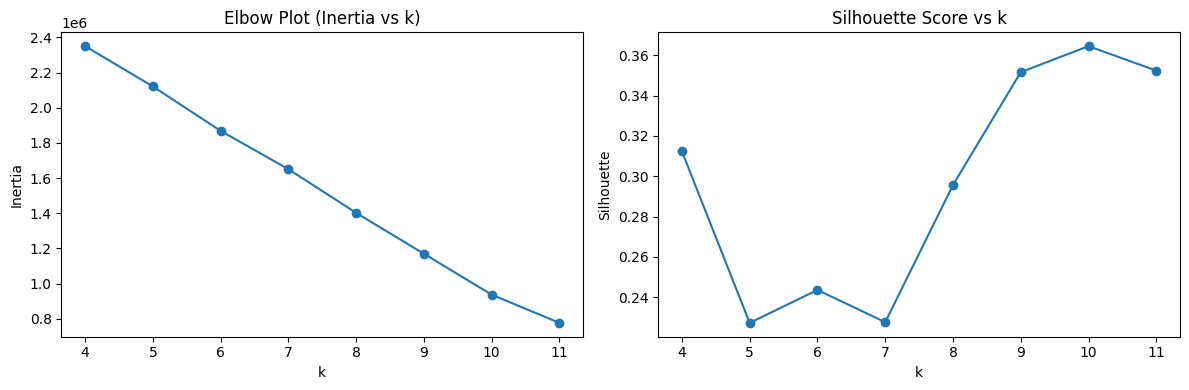

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# X should already exist (your FAMD matrix, e.g., X = X10_32)

# --- 1) Get silhouette series from your existing results ---
if "kmeans_results" in globals():
    ks = kmeans_results["k"].tolist()
    sil_scores = kmeans_results["silhouette"].tolist()
else:
    ks = k_list
    sil_scores = sil

# --- 2) Compute inertia for elbow (cheap + full-data safe) ---
inertia = []
for k in ks:
    km = KMeans(n_clusters=int(k), n_init="auto", random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Optional: combine into one table
eval_df = pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil_scores})
display(eval_df)

# --- 3) Plot: Elbow + Silhouette (two panels) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow Plot (Inertia vs k)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, sil_scores, marker="o")
ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()



## KMeans Clustering

In [18]:
from sklearn.cluster import KMeans

# Fit KMeans with k = 10
k_final = 9
km_final = KMeans(
    n_clusters=k_final,
    n_init="auto",
    random_state=42
)

df["cluster"] = km_final.fit_predict(X)
print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    20232
1     6938
2      663
3    20846
4      845
5     1511
6     4762
7      453
8     5160
Name: count, dtype: int64


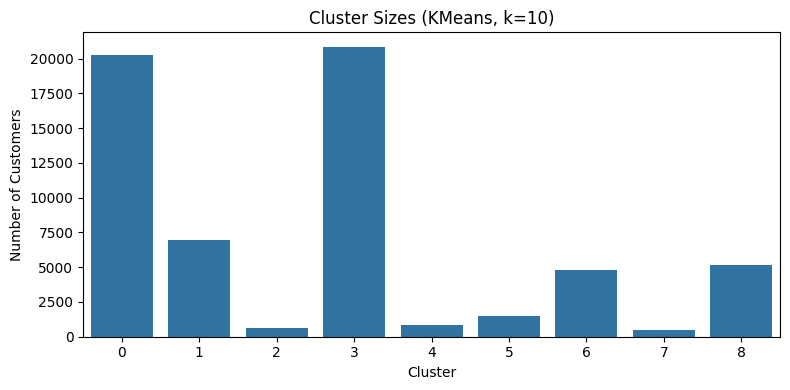

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_sizes = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.title("Cluster Sizes (KMeans, k=10)")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## Result Analysis & Visualizations

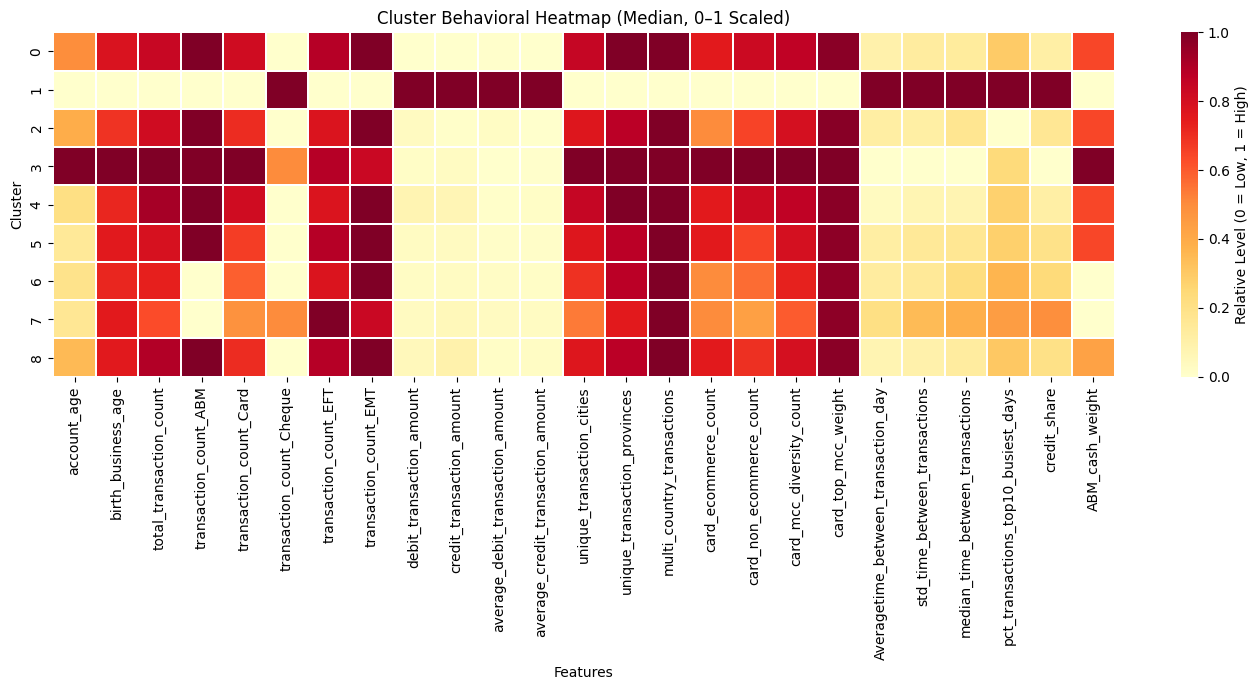

In [20]:
import numpy as np

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# 0–1 scale per feature
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

# Drop non-informative columns (all-white)
cluster_medians_01 = cluster_medians_01.loc[:, cluster_medians_01.max() > 0]

plt.figure(figsize=(14, 7))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [21]:


for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    print(f"{cluster}:")
    print(f"  High (0.65-1.0): {list(high_features.index)}")
    print(f"  Moderate (0.35-0.65): {list(moderate_features.index)}")
    print()


0:
  High (0.65-1.0): ['transaction_count_ABM', 'transaction_count_EMT', 'unique_transaction_provinces', 'multi_country_transactions', 'card_top_mcc_weight', 'transaction_count_EFT', 'card_mcc_diversity_count', 'unique_transaction_cities', 'total_transaction_count', 'card_non_ecommerce_count', 'transaction_count_Card', 'birth_business_age', 'card_ecommerce_count']
  Moderate (0.35-0.65): ['ABM_cash_weight', 'account_age']

1:
  High (0.65-1.0): ['transaction_count_Cheque', 'debit_transaction_amount', 'credit_transaction_amount', 'average_debit_transaction_amount', 'average_credit_transaction_amount', 'Averagetime_between_transaction_day', 'std_time_between_transactions', 'median_time_between_transactions', 'pct_transactions_top10_busiest_days', 'credit_share']
  Moderate (0.35-0.65): []

2:
  High (0.65-1.0): ['transaction_count_ABM', 'transaction_count_EMT', 'multi_country_transactions', 'card_top_mcc_weight', 'unique_transaction_provinces', 'total_transaction_count', 'card_mcc_divers

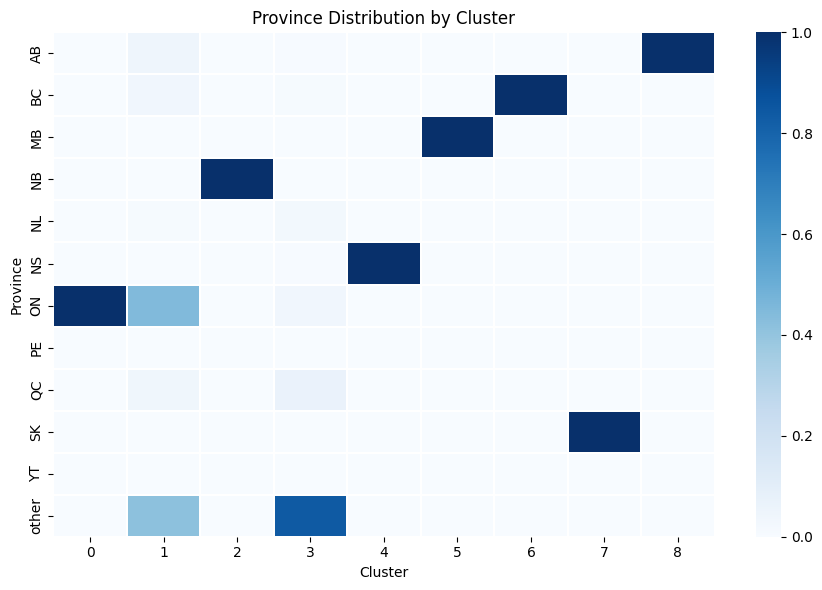

In [22]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    province_dist,
    cmap="Blues",
    linewidths=0.3
)

plt.title("Province Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()


C:\Users\houju\AppData\Local\Temp\ipykernel_66344\1414185188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.index, y=vals.values, palette="Set2")
C:\Users\houju\AppData\Local\Temp\ipykernel_66344\1414185188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.index, y=vals.values, palette="Set2")
C:\Users\houju\AppData\Local\Temp\ipykernel_66344\1414185188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.index, y=vals.values, palette="Set2")
C:\Users\houju\AppData\Local\Temp\ipykernel_66344\1414185188.py:11: Fu

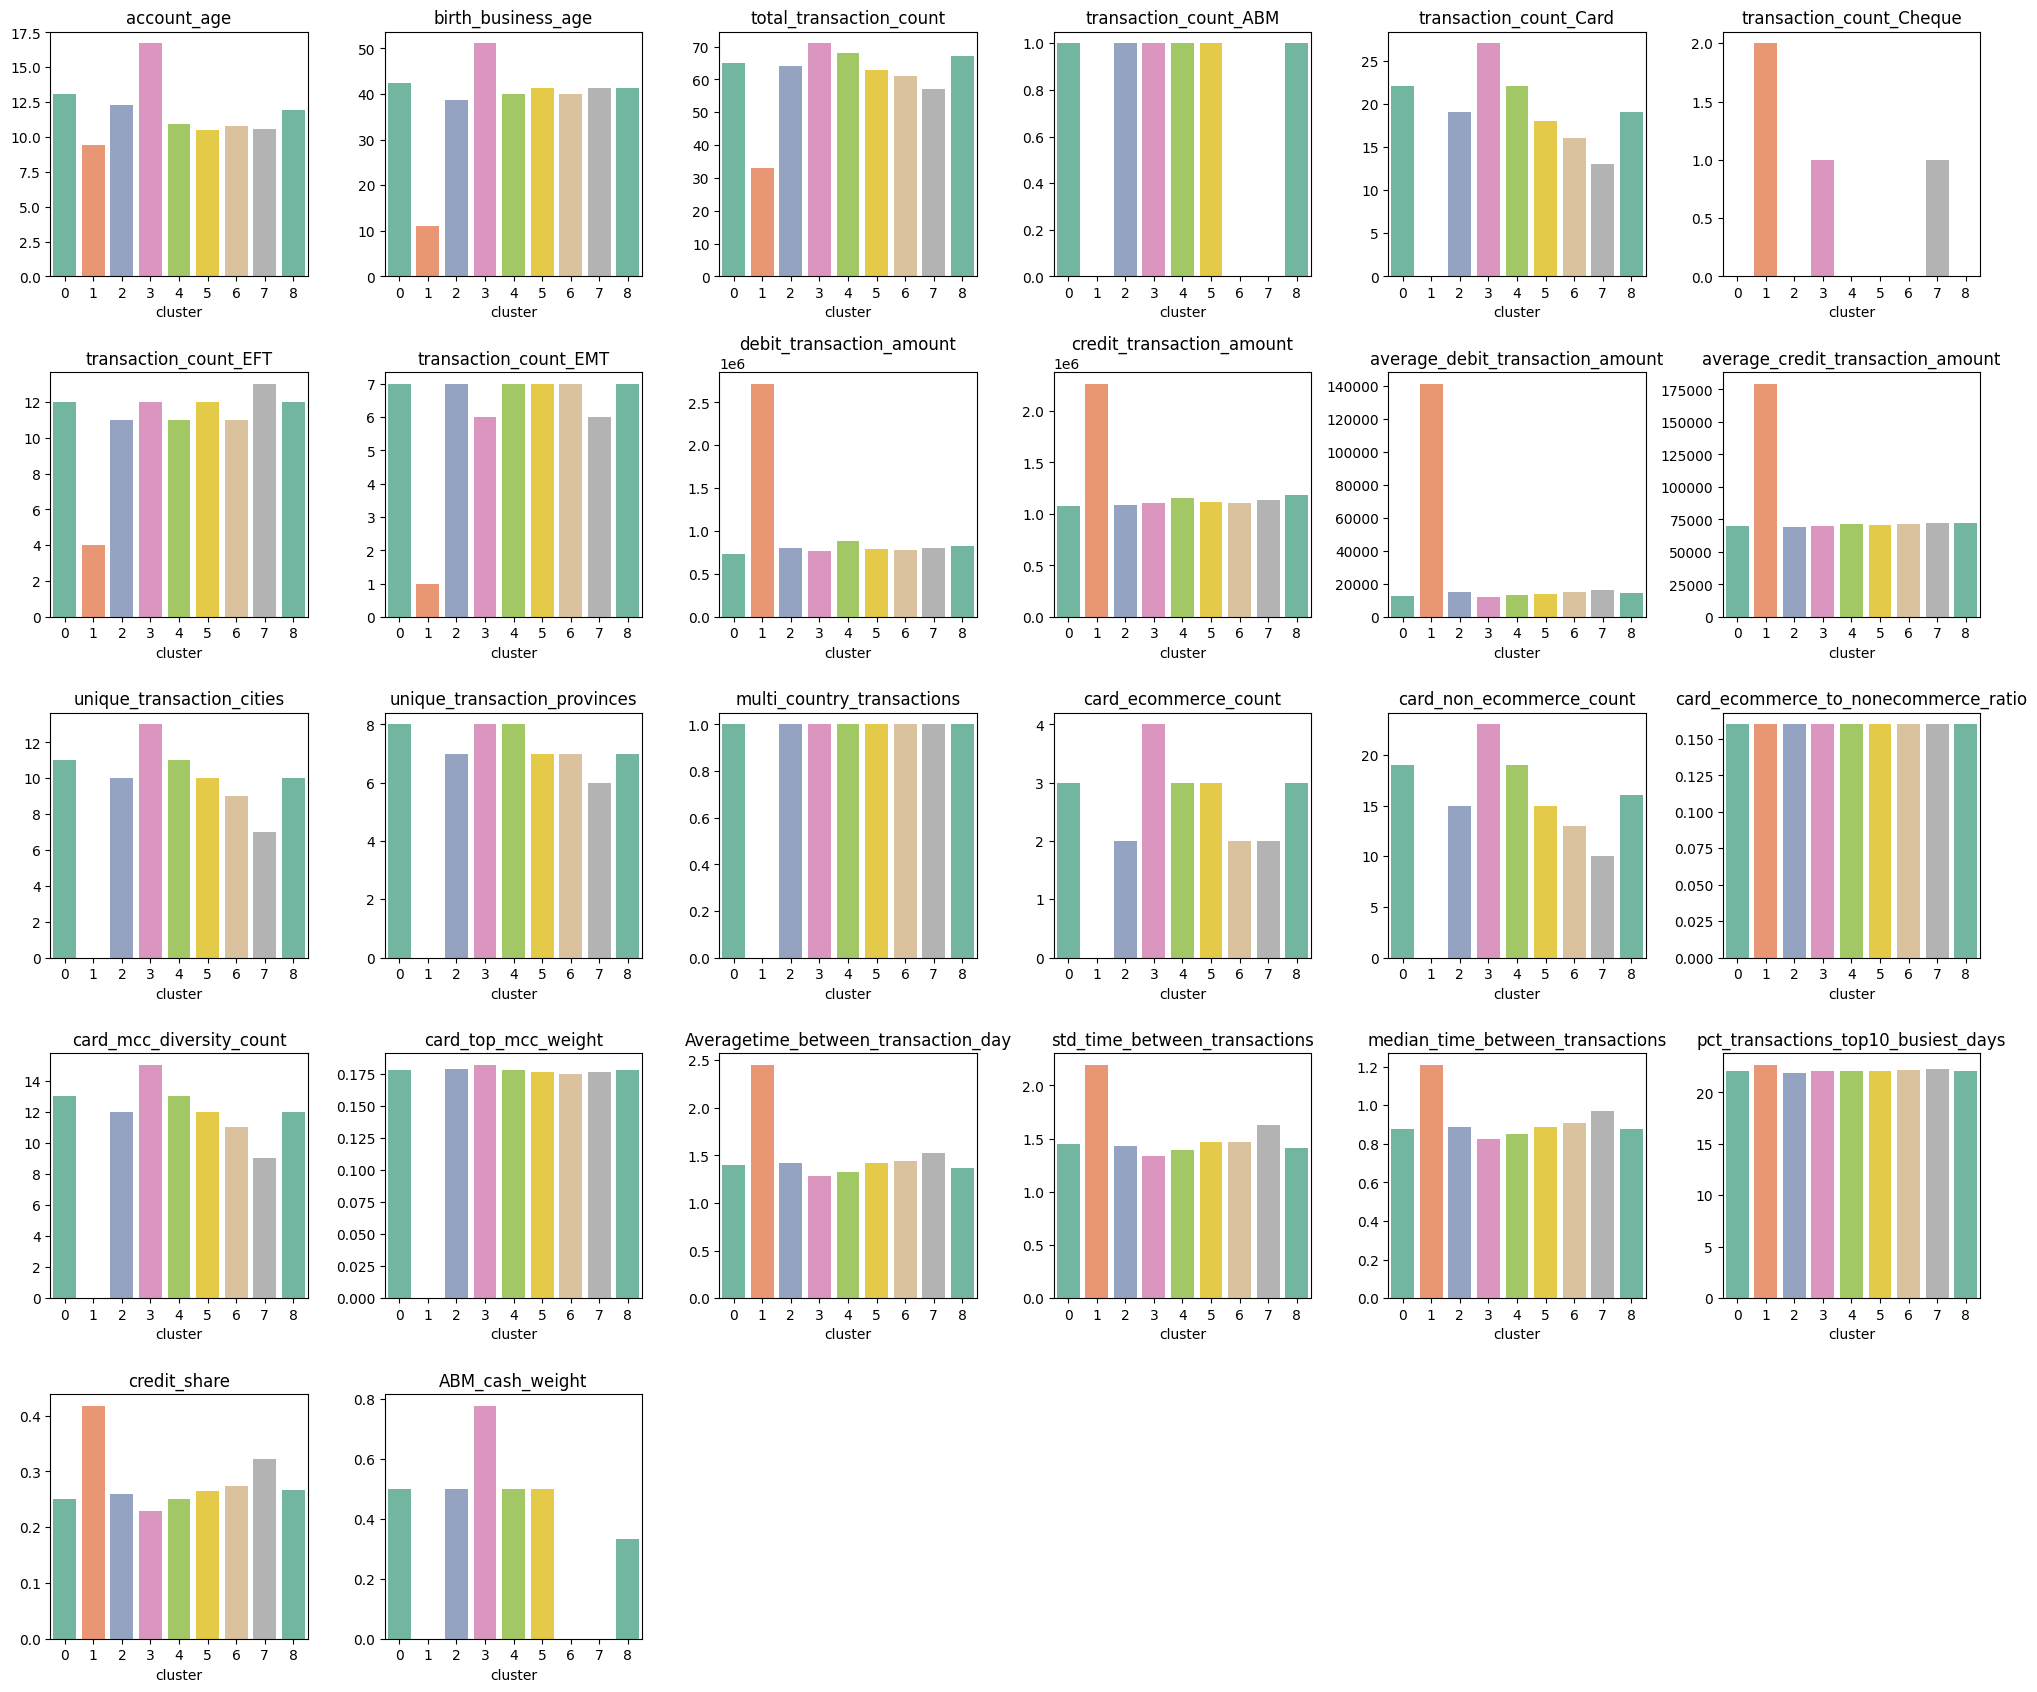

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

fig = plt.figure(figsize=(20, 20))

for i, col in enumerate(num_cols):
    plt.subplot(6, 6, i+1)  # adjust grid if needed
    vals = df.groupby("cluster")[col].median()
    sns.barplot(x=vals.index, y=vals.values, palette="Set2")
    plt.title(col)
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


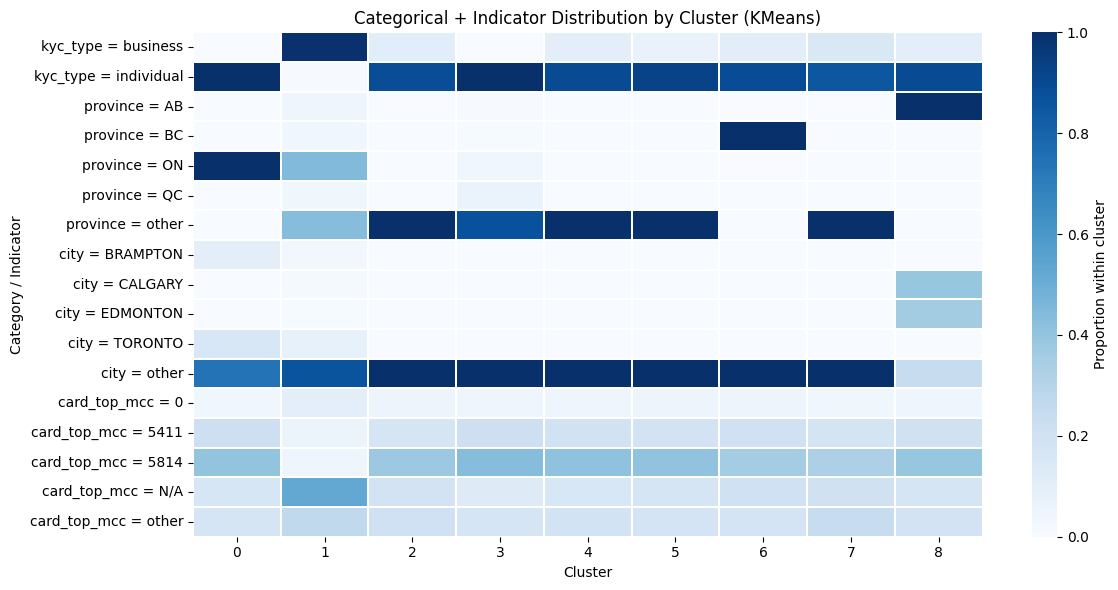

In [24]:


cluster_col = "cluster"

categorical_cols = [
    "kyc_type",
    "province",
    "city",
    "card_top_mcc"
]

top_n = 5
heatmap_blocks = []

# ---- categorical variables (top-N + other) ----
# First normalize case: convert any "Other" to "other" to match existing data
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("Other", "other", regex=False)

for col in categorical_cols:
    top_vals = df[col].value_counts().head(top_n).index
    collapsed = df[col].where(df[col].isin(top_vals), "other")

    ct = pd.crosstab(
        collapsed,
        df[cluster_col],
        normalize="columns"
    )

    ct.index = [f"{col} = {v}" for v in ct.index]
    heatmap_blocks.append(ct)

# ---- combine everything ----
heatmap_df = pd.concat(heatmap_blocks)

# ---- plot ----
plt.figure(figsize=(12, max(6, 0.35 * heatmap_df.shape[0])))

sns.heatmap(
    heatmap_df,
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Proportion within cluster"}
)

plt.title("Categorical + Indicator Distribution by Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Category / Indicator")
plt.tight_layout()
plt.show()


In [25]:
# Save final dataframe with clusters
# First, restore customer_id from original dataset
original_csv_path = "../Clustering/clustering_Cleaned.csv"
df_original = pd.read_csv(original_csv_path)

# Safety check: verify row counts match
if len(df_original) != len(df):
    raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df)}. Cannot safely restore customer_id.")

# Add customer_id back to the final dataframe using index alignment (safer than assuming order)
if 'customer_id' in df_original.columns:
    # Use index-based assignment to ensure correct alignment
    # Reset index to ensure both dataframes have 0, 1, 2, ... indices
    df_original_reset = df_original.reset_index(drop=True)
    df_reset = df.reset_index(drop=True)
    
    # Verify indices match
    if not df_reset.index.equals(df_original_reset.index):
        raise ValueError("Index mismatch! Cannot safely restore customer_id.")
    
    # Assign customer_id using index alignment
    df['customer_id'] = df_original_reset['customer_id'].values
    print(f"✓ customer_id restored from original dataset")
    print(f"  Verified: {len(df)} rows match between original and processed data")
else:
    raise ValueError("customer_id not found in original dataset!")

# Reorder columns to put customer_id first
cols = ['customer_id'] + [col for col in df.columns if col != 'customer_id']
df = df[cols]

# Create business_act_like_individual indicator column
# If kyc_type is "business" AND cluster label is NOT 1, then 1, otherwise 0
df['business_act_like_individual'] = (
    (df['kyc_type'].str.lower() == 'business') & (df['cluster'] != 1)
).astype(int)

print(f"\n✓ Created 'business_act_like_individual' indicator column")
print(f"  Total rows with indicator = 1: {df['business_act_like_individual'].sum()}")
print(f"  Total rows with indicator = 0: {(df['business_act_like_individual'] == 0).sum()}")

# Save to CSV
output_path = "../Clustering/Kmeans_Final.csv"
df.to_csv(output_path, index=False)
print(f"\n✓ Final dataframe saved to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"\nCluster distribution:")
print(df["cluster"].value_counts().sort_index())



✓ customer_id restored from original dataset
  Verified: 61410 rows match between original and processed data

✓ Created 'business_act_like_individual' indicator column
  Total rows with indicator = 1: 1421
  Total rows with indicator = 0: 59989

✓ Final dataframe saved to: ../Clustering/Kmeans_Final.csv
  Shape: (61410, 34)
  Columns: 34

Cluster distribution:
cluster
0    20232
1     6938
2      663
3    20846
4      845
5     1511
6     4762
7      453
8     5160
Name: count, dtype: int64


In [26]:
# Create a transposed DataFrame
transposed_df = df.transpose()

# Get a boolean mask for duplicate columns (as rows in the transposed df)
# keep='first' marks the first occurrence as False and all others as True
duplicate_columns_mask = transposed_df.duplicated(keep='first')

# Get the names of the columns that are duplicates
duplicate_column_names_by_value = df.columns[duplicate_columns_mask]

duplicate_column_names_by_value

Index([], dtype='object')

## Refine Business Dominant Cluster1

Extract cluster 1 subset, rerun preprocessing + FAMD pipeline, and create refined subclusters.

In [27]:
# Extract subset where cluster label is 1 (business-dominant macro cluster)
# Capture original row count for validation
original_row_count = len(df)

cluster_1_mask = df['cluster'] == 1
cluster_1_indices = df[cluster_1_mask].index.tolist()

print(f"Original dataset size: {original_row_count} rows")
print(f"Cluster 1 size: {cluster_1_mask.sum()} rows")
print(f"Cluster 1 percentage: {cluster_1_mask.sum() / len(df) * 100:.2f}%")
print(f"\nCluster 1 kyc_type distribution:")
print(df[cluster_1_mask]['kyc_type'].value_counts())

Original dataset size: 61410 rows
Cluster 1 size: 6938 rows
Cluster 1 percentage: 11.30%

Cluster 1 kyc_type distribution:
kyc_type
business      6890
individual      48
Name: count, dtype: int64


In [28]:
# Reload original data and extract the same subset for preprocessing
original_csv_path = "../Clustering/clustering_Cleaned.csv"
df_original = pd.read_csv(original_csv_path)

# Extract subset using the same indices
df_subset_original = df_original.iloc[cluster_1_indices].copy().reset_index(drop=True)

print(f"Subset shape: {df_subset_original.shape}")
print(f"Subset kyc_type distribution:")
print(df_subset_original['kyc_type'].value_counts())

Subset shape: (6938, 44)
Subset kyc_type distribution:
kyc_type
business      6890
individual      48
Name: count, dtype: int64


## Subset Data Preprocessing

In [29]:
df_subset = df_subset_original.copy()

# 1. Merge industry_code and occupation_code into economic_role
both_null_mask = df_subset["industry_code"].isna() & df_subset["occupation_code"].isna()

df_subset["economic_role"] = np.where(
    df_subset["kyc_type"].str.lower() == "business",
    "BUSINESS_" + df_subset["industry_code"].astype(str),
    "INDIVIDUAL_" + df_subset["occupation_code"].astype(str)
)

df_subset.loc[both_null_mask, "economic_role"] = "Both_N/A"

df_subset["economic_role"] = df_subset["economic_role"].replace(
    {
        "BUSINESS_nan": np.nan,
        "INDIVIDUAL_nan": np.nan,
        "BUSINESS_N/A": np.nan,
        "INDIVIDUAL_N/A": np.nan,
        "BUSINESS_None": np.nan,
        "INDIVIDUAL_None": np.nan,
    }
)

df_subset["economic_role"] = df_subset["economic_role"].astype("category")

df_subset = df_subset.drop(columns=["industry_code", "occupation_code"])

print("economic_role created")

economic_role created


In [30]:
# 2. Replace rare economic_role values (same threshold: < 50)
if 'economic_role' in df_subset.columns:
    economic_role_counts = df_subset['economic_role'].value_counts()
    rare_economic_roles = economic_role_counts[economic_role_counts < 50].index.tolist()
    
    print(f"Found {len(rare_economic_roles)} rare economic_role values in subset")
    
    rare_mask = df_subset['economic_role'].isin(rare_economic_roles)
    df_subset.loc[rare_mask & (df_subset['kyc_type'].str.lower() == 'business'), 'economic_role'] = 'BUSINESS_Other'
    df_subset.loc[rare_mask & (df_subset['kyc_type'].str.lower() != 'business'), 'economic_role'] = 'INDIVIDUAL_OTHER'
    
    df_subset['economic_role'] = df_subset['economic_role'].astype('category')
    
    print(f"Rare economic_role values replaced")

Found 159 rare economic_role values in subset
Rare economic_role values replaced


In [31]:
# 3. Fill column NAN and Engineer credit_share and handle transaction count columns
df_subset['account_age'] = df_subset['account_age'].fillna(df_subset['account_age'].median())
df_subset['birth_business_age'] = df_subset['birth_business_age'].fillna(df_subset['birth_business_age'].median())

print("account_age and birth_business_age filled")

if 'debit_transaction_count' in df_subset.columns:
    df_subset['debit_transaction_count'] = df_subset['debit_transaction_count'].fillna(0)
if 'credit_transaction_count' in df_subset.columns:
    df_subset['credit_transaction_count'] = df_subset['credit_transaction_count'].fillna(0)
if 'total_transaction_count' in df_subset.columns:
    df_subset['total_transaction_count'] = df_subset['total_transaction_count'].fillna(0)

if 'credit_transaction_count' in df_subset.columns and 'total_transaction_count' in df_subset.columns:
    df_subset['credit_share'] = np.where(
        df_subset['total_transaction_count'] > 0,
        df_subset['credit_transaction_count'] / df_subset['total_transaction_count'],
        0
    )
    
    cols_to_drop = []
    if 'debit_transaction_count' in df_subset.columns:
        cols_to_drop.append('debit_transaction_count')
    if 'credit_transaction_count' in df_subset.columns:
        cols_to_drop.append('credit_transaction_count')
    
    if cols_to_drop:
        df_subset = df_subset.drop(columns=cols_to_drop)

# Fill debit/credit amount columns
debit_credit_amount_cols = [
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_amount_cols:
    if col in df_subset.columns:
        df_subset[col] = df_subset[col].fillna(0)

# Rename column
if 'Averagetime_between_alltransaction' in df_subset.columns:
    df_subset = df_subset.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})

# Fill other columns
for col in ['Debit_Amount_Total', 'Credit_Amount_Total']:
    if col in df_subset.columns:
        df_subset[col] = df_subset[col].fillna(0)

if 'Averagetime_between_transaction_day' in df_subset.columns:
    median_value = df_subset['Averagetime_between_transaction_day'].median()
    df_subset['Averagetime_between_transaction_day'] = df_subset['Averagetime_between_transaction_day'].fillna(median_value)

if 'std_time_between_transactions' in df_subset.columns:
    median_value = df_subset['std_time_between_transactions'].median()
    df_subset['std_time_between_transactions'] = df_subset['std_time_between_transactions'].fillna(median_value)

if 'median_time_between_transactions' in df_subset.columns:
    median_value = df_subset['median_time_between_transactions'].median()
    df_subset['median_time_between_transactions'] = df_subset['median_time_between_transactions'].fillna(median_value)

print("Transaction features engineered and filled")

account_age and birth_business_age filled
Transaction features engineered and filled


In [32]:
# 4. Engineer ABM_cash_weight and handle ABM columns
if 'abm_cash_count' in df_subset.columns and 'abm_non_cash_count' in df_subset.columns:
    denominator = df_subset['abm_cash_count'].fillna(0) + df_subset['abm_non_cash_count'].fillna(0)
    df_subset['ABM_cash_weight'] = np.where(
        denominator > 0,
        df_subset['abm_cash_count'].fillna(0) / denominator,
        0
    )
    df_subset = df_subset.drop(columns=['abm_cash_count', 'abm_non_cash_count'])

# Deal with NAN
card_abm_cols = [col for col in df_subset.columns if col.startswith('card_') or col.startswith('abm_')]
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df_subset[col] = df_subset[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df_subset[col] = df_subset[col].fillna('N/A')
    elif col == 'card_ecommerce_to_nonecommerce_ratio':
        df_subset[col] = df_subset[col].fillna(df_subset[col].median())
    else:
        df_subset[col] = df_subset[col].fillna(0)

print("ABM features engineered")
# 5. Replace rare MCC codes (< 100 occurrences)
if 'card_top_mcc' in df_subset.columns:
    mcc_counts = df_subset['card_top_mcc'].value_counts()
    rare_mccs = mcc_counts[mcc_counts < 100].index.tolist()
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    df_subset.loc[df_subset['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'

print("Rare MCC codes replaced")
# 6. Replace rare cities (< 100 occurrences)
if 'city' in df_subset.columns:
    city_counts = df_subset['city'].value_counts()
    rare_cities = city_counts[city_counts < 100].index.tolist()
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    df_subset.loc[df_subset['city'].isin(rare_cities), 'city'] = 'other'

print("Rare cities replaced")

ABM features engineered
Rare MCC codes replaced
Rare cities replaced


In [33]:
# 7. Handle infinite and NAN
numeric_cols = df_subset.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if np.isinf(df_subset[col]).any():
        df_subset[col] = df_subset[col].replace([np.inf, -np.inf], np.nan).fillna(0)

nan_counts = df_subset[numeric_cols].isna().sum()
if nan_counts.sum() > 0:
    df_subset[numeric_cols] = df_subset[numeric_cols].fillna(0)

print("Infinite and NaN values handled")
# 8. Drop sales_cents, customer_id, card_second_mcc, kyc_type
df_subset_for_famd = df_subset.drop(columns=['kyc_type']) if 'kyc_type' in df_subset.columns else df_subset
if 'sales_cents' in df_subset.columns:
    df_subset = df_subset.drop(columns=['sales_cents'])
if 'customer_id' in df_subset.columns:
    df_subset = df_subset.drop(columns=['customer_id'])
if 'card_second_mcc' in df_subset.columns:
    df_subset = df_subset.drop(columns=['card_second_mcc'])
if 'transaction_count_Western Union' in df_subset.columns:
    df_subset = df_subset.drop(columns=['transaction_count_Western Union'])
if 'transaction_count_Wire' in df_subset.columns:
    df_subset = df_subset.drop(columns=['transaction_count_Wire'])
if 'abm_cash_to_non_cash_ratio' in df_subset.columns:
    df_subset = df_subset.drop(columns=['abm_cash_to_non_cash_ratio'])

print("Unnecessary columns dropped")
print(f"Note: kyc_type excluded from clustering but kept in original df_subset")
# 9. Data type cleanup
categorical_cols = df_subset.select_dtypes(include=['object', 'category']).columns.tolist()
non_categorical_cols = [col for col in df_subset.columns if col not in categorical_cols]

for col in non_categorical_cols:
    df_subset[col] = df_subset[col].astype('float64')

print(f"  Categorical columns: {len(categorical_cols)}")
print(f"  Float64 columns: {len(non_categorical_cols)}")
print(f"  Total columns: {len(df_subset.columns)}")

Infinite and NaN values handled
Unnecessary columns dropped
Note: kyc_type excluded from clustering but kept in original df_subset
  Categorical columns: 5
  Float64 columns: 30
  Total columns: 35


In [34]:
df_subset.isna().sum()

kyc_type                                0
province                                0
city                                    0
account_age                             0
birth_business_age                      0
total_transaction_count                 0
transaction_count_ABM                   0
transaction_count_Card                  0
transaction_count_Cheque                0
transaction_count_EFT                   0
transaction_count_EMT                   0
debit_transaction_amount                0
credit_transaction_amount               0
average_debit_transaction_amount        0
average_credit_transaction_amount       0
unique_transaction_cities               0
unique_transaction_provinces            0
multi_country_transactions              0
card_transaction_count                  0
card_ecommerce_count                    0
card_non_ecommerce_count                0
card_ecommerce_to_nonecommerce_ratio    0
card_mcc_diversity_count                0
card_top_mcc_weight               

### Fit FAMD on Subset with Multiple n_components

In [35]:
# Fit FAMD with n_components=6, 8, 10 on the subset
famd_models = {}
famd_scores = {}

for n_comp in [6, 8, 10]:
    print(f"\nFitting FAMD with n_components={n_comp}")
    famd_subset = prince.FAMD(
        n_components=n_comp,
        n_iter=3,
        copy=True,
        check_input=True,
        random_state=42,
        engine="sklearn",
        handle_unknown="error"
    )
    famd_subset = famd_subset.fit(df_subset)
    famd_models[n_comp] = famd_subset
    
    # Transform to FAMD coordinates
    X_famd_subset = famd_subset.row_coordinates(df_subset)
    famd_scores[n_comp] = X_famd_subset.iloc[:, :n_comp].to_numpy().astype(np.float32)
    print(f" FAMD fitted and transformed. Shape: {famd_scores[n_comp].shape}")

print(f"\n All FAMD models fitted successfully")
# Compare k=4 to 10 using silhouette and elbow for each n_component
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_list = list(range(4, 11))
results_subset = []

for n_comp in [6, 8, 10]:
    X = famd_scores[n_comp]
    print(f"Evaluating n_components={n_comp}")
    
    sil_scores = []
    inertia_scores = []
    
    for k in k_list:
        km = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
        inertia_scores.append(km.inertia_)
        
        results_subset.append({
            'n_components': n_comp,
            'k': k,
            'silhouette': sil,
            'inertia': km.inertia_
        })

results_df = pd.DataFrame(results_subset)
display(results_df)


Fitting FAMD with n_components=6
 FAMD fitted and transformed. Shape: (6938, 6)

Fitting FAMD with n_components=8
 FAMD fitted and transformed. Shape: (6938, 8)

Fitting FAMD with n_components=10
 FAMD fitted and transformed. Shape: (6938, 10)

 All FAMD models fitted successfully
Evaluating n_components=6
Evaluating n_components=8
Evaluating n_components=10


,n_components,k,silhouette,inertia
0,6,4,0.237028,123384.078125
1,6,5,0.269403,108207.031250
2,6,6,0.306683,89013.953125
3,6,7,0.322346,76903.109375
4,6,8,0.336749,63405.484375
5,6,9,0.340754,56740.843750
6,6,10,0.334100,54248.894531
7,8,4,0.287539,163295.156250
8,8,5,0.283071,140534.031250
9,8,6,0.260145,129952.234375


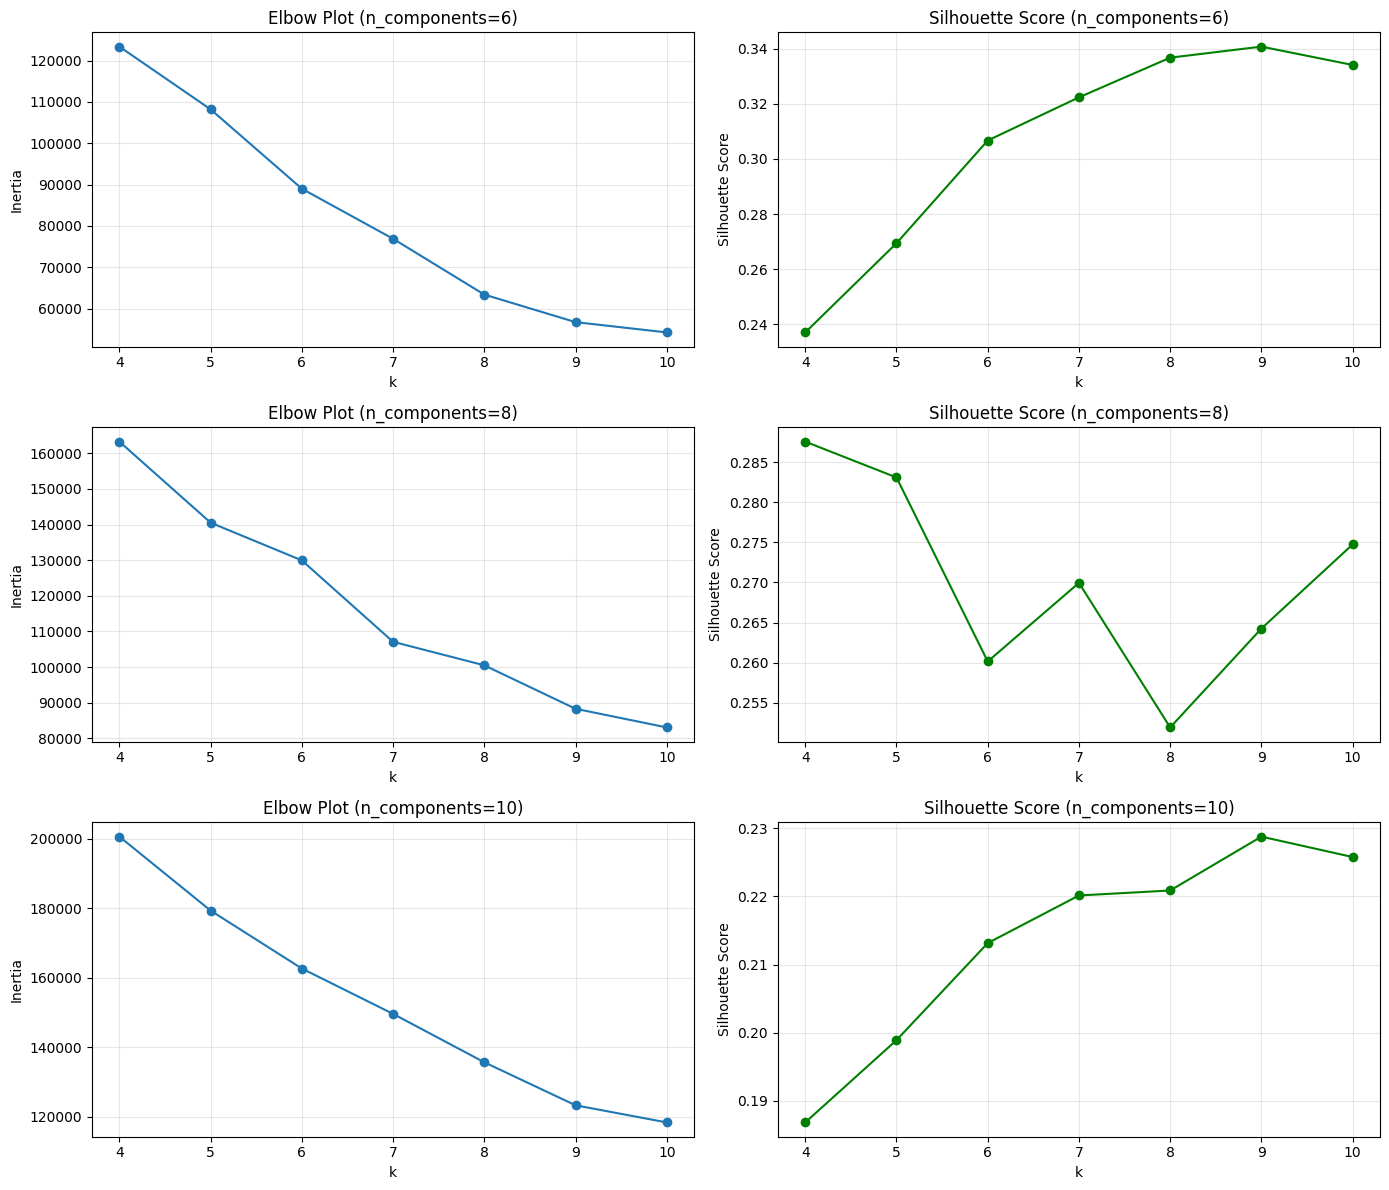

In [36]:
# Visualize silhouette and elbow plots for each n_component
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, n_comp in enumerate([6, 8, 10]):
    subset_results = results_df[results_df['n_components'] == n_comp]
    
    # Elbow plot
    axes[idx, 0].plot(subset_results['k'], subset_results['inertia'], marker='o')
    axes[idx, 0].set_title(f'Elbow Plot (n_components={n_comp})')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Silhouette plot
    axes[idx, 1].plot(subset_results['k'], subset_results['silhouette'], marker='o', color='green')
    axes[idx, 1].set_title(f'Silhouette Score (n_components={n_comp})')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Silhouette Score')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Transform subset to FAMD coordinates for best n_component and run KMeans
best_n_comp = 6
best_k = 7
X_best = famd_scores[best_n_comp]

km_subset = KMeans(
    n_clusters=best_k,
    n_init="auto",
    random_state=42
)

subset_refined_labels = km_subset.fit_predict(X_best)

refined_counts = pd.Series(subset_refined_labels).value_counts().sort_index()

# Create refined labels with prefix "business_"
df_subset['refined_cluster'] = subset_refined_labels
df_subset['refined_label'] = 'business_' + df_subset['refined_cluster'].astype(str)

print(f"\nRefined labels created:")
print(df_subset['refined_label'].value_counts().sort_index())


Refined labels created:
refined_label
business_0     193
business_1    1361
business_2    2533
business_3      48
business_4    1855
business_5     264
business_6     684
Name: count, dtype: int64


In [38]:
# Create final_label column in main dataframe
# All rows keep original global label except cluster 1 rows which get refined labels

# Initialize final_label with original cluster labels (as strings)
df['final_label'] = df['cluster'].astype(str)

# Create a mapping from original index to refined label for cluster 1 rows
# We need to map back to the original dataframe indices
refined_label_map = {}
for i, orig_idx in enumerate(cluster_1_indices):
    refined_label_map[orig_idx] = df_subset.iloc[i]['refined_label']

# Replace cluster 1 labels with refined labels
for orig_idx, refined_label in refined_label_map.items():
    df.loc[orig_idx, 'final_label'] = refined_label

print(f"Final label distribution:")
print(df['final_label'].value_counts().sort_index())

Final label distribution:
final_label
0             20232
2               663
3             20846
4               845
5              1511
6              4762
7               453
8              5160
business_0      193
business_1     1361
business_2     2533
business_3       48
business_4     1855
business_5      264
business_6      684
Name: count, dtype: int64


In [39]:
# Validation 1: Row counts are unchanged
current_row_count = len(df)
print(f"Row counts match: {original_row_count == current_row_count}")
# Validation 2: No missing labels exist
missing_labels = df['final_label'].isna().sum()
print(f"No missing labels: {missing_labels == 0}")

Row counts match: True
No missing labels: True


## Visualizations for Refined Cluster1 Subclusters

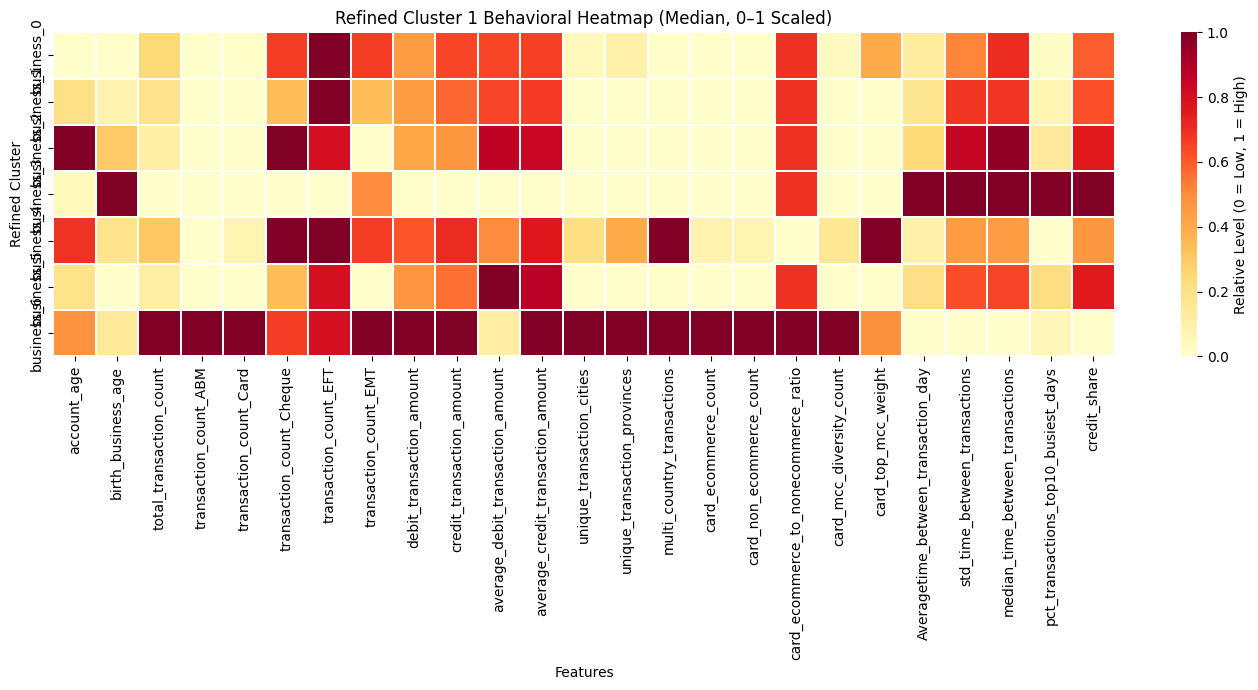

In [40]:
# Create heatmaps for refined cluster 1 subclusters (business_* labels only)
# Filter to only refined clusters (those with business_ prefix)
refined_clusters_df = df[df['final_label'].str.startswith('business_', na=False)].copy()

if len(refined_clusters_df) > 0:
    # 1. Behavioral Heatmap (Numeric features)
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    num_cols = refined_clusters_df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")
    
    # Cluster medians
    cluster_medians = refined_clusters_df.groupby("final_label")[num_cols].median()
    
    # 0–1 scale per feature
    cluster_medians_01 = (
        cluster_medians - cluster_medians.min()
    ) / (cluster_medians.max() - cluster_medians.min())
    
    # Drop non-informative columns (all-white)
    cluster_medians_01 = cluster_medians_01.loc[:, cluster_medians_01.max() > 0]
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        cluster_medians_01,
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0.3,
        cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
    )
    
    plt.title("Refined Cluster 1 Behavioral Heatmap (Median, 0–1 Scaled)")
    plt.xlabel("Features")
    plt.ylabel("Refined Cluster")
    plt.tight_layout()
    plt.show()
else:
    print("No refined clusters found with 'business_' prefix")

In [41]:

for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    print(f"{cluster}:")
    print(f"  High (0.65-1.0): {list(high_features.index)}")
    print(f"  Moderate (0.35-0.65): {list(moderate_features.index)}")
    print()

business_0:
  High (0.65-1.0): ['transaction_count_EFT', 'median_time_between_transactions', 'card_ecommerce_to_nonecommerce_ratio', 'transaction_count_Cheque', 'transaction_count_EMT', 'average_credit_transaction_amount']
  Moderate (0.35-0.65): ['average_debit_transaction_amount', 'credit_transaction_amount', 'credit_share', 'std_time_between_transactions', 'debit_transaction_amount', 'card_top_mcc_weight']

business_1:
  High (0.65-1.0): ['transaction_count_EFT', 'card_ecommerce_to_nonecommerce_ratio', 'median_time_between_transactions', 'std_time_between_transactions', 'average_credit_transaction_amount', 'average_debit_transaction_amount']
  Moderate (0.35-0.65): ['credit_share', 'credit_transaction_amount', 'debit_transaction_amount']

business_2:
  High (0.65-1.0): ['account_age', 'transaction_count_Cheque', 'median_time_between_transactions', 'average_debit_transaction_amount', 'std_time_between_transactions', 'average_credit_transaction_amount', 'transaction_count_EFT', 'credi

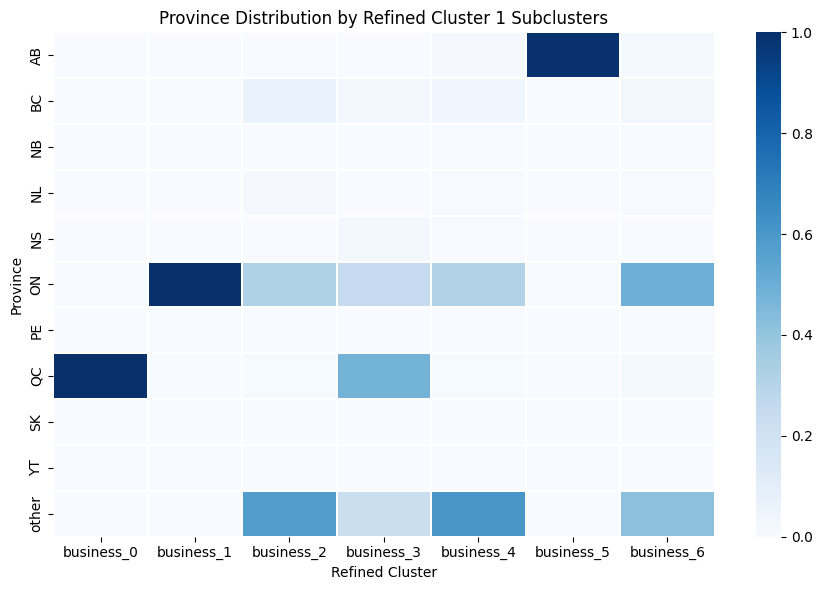

In [42]:
# 2. Province Distribution Heatmap for Refined Clusters
if len(refined_clusters_df) > 0:
    province_dist = pd.crosstab(
        refined_clusters_df["province"],
        refined_clusters_df["final_label"],
        normalize="columns"
    )
    
    plt.figure(figsize=(9, 6))
    sns.heatmap(
        province_dist,
        cmap="Blues",
        linewidths=0.3
    )
    
    plt.title("Province Distribution by Refined Cluster 1 Subclusters")
    plt.xlabel("Refined Cluster")
    plt.ylabel("Province")
    plt.tight_layout()
    plt.show()

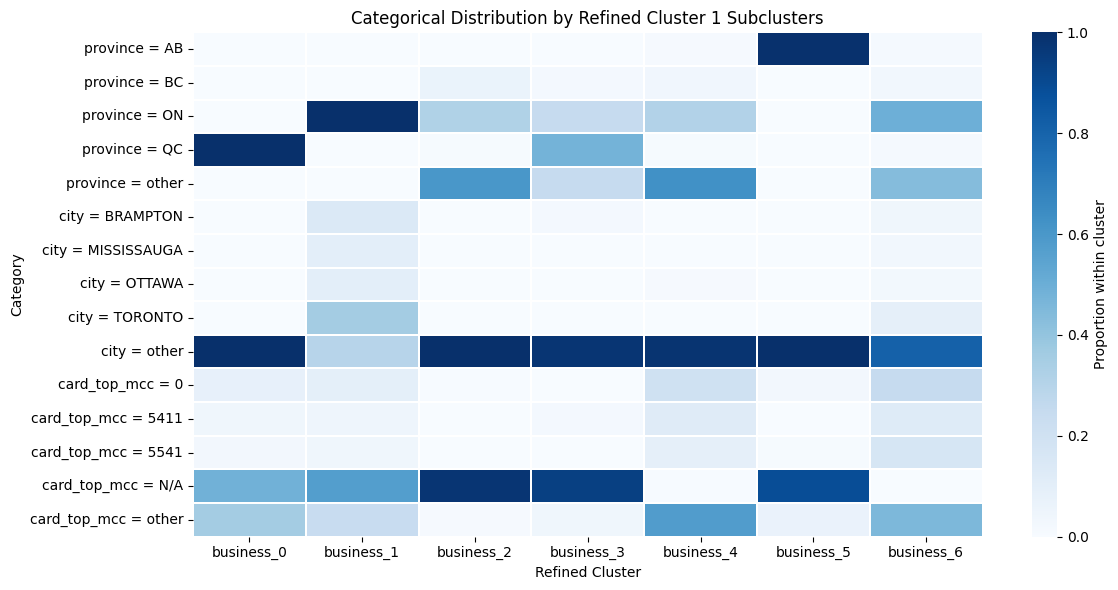

In [43]:
# 3. Categorical Distribution Heatmap for Refined Clusters
if len(refined_clusters_df) > 0:
    cluster_col = "final_label"
    
    categorical_cols = [
        "province",
        "city",
        "card_top_mcc"
    ]
    
    top_n = 5
    heatmap_blocks = []
    
    # categorical variables (5/other)
    for col in categorical_cols:
        if col in refined_clusters_df.columns:
            refined_clusters_df[col] = refined_clusters_df[col].astype(str).str.replace("Other", "other", regex=False)
    
    for col in categorical_cols:
        if col in refined_clusters_df.columns:
            top_vals = refined_clusters_df[col].value_counts().head(top_n).index
            collapsed = refined_clusters_df[col].where(refined_clusters_df[col].isin(top_vals), "other")
            
            ct = pd.crosstab(
                collapsed,
                refined_clusters_df[cluster_col],
                normalize="columns"
            )
            
            ct.index = [f"{col} = {v}" for v in ct.index]
            heatmap_blocks.append(ct)
    
    # combine everything
    if heatmap_blocks:
        heatmap_df = pd.concat(heatmap_blocks)
        plt.figure(figsize=(12, max(6, 0.35 * heatmap_df.shape[0])))
        
        sns.heatmap(
            heatmap_df,
            cmap="Blues",
            vmin=0,
            vmax=1,
            linewidths=0.3,
            cbar_kws={"label": "Proportion within cluster"}
        )
        
        plt.title("Categorical Distribution by Refined Cluster 1 Subclusters")
        plt.xlabel("Refined Cluster")
        plt.ylabel("Category")
        plt.tight_layout()
        plt.show()

In [44]:

# Define cluster_1_final: final labels for cluster 1 rows
cluster_1_final = df[df['cluster'] == 1]['final_label']

# Validation 3: Only cluster 1 was relabeled
# Check that rows outside cluster 1 were not relabeled (they should keep their original cluster label as string)
relabeled_outside_cluster_1 = ((df['cluster'] != 1) & (df['final_label'] != df['cluster'].astype(str))).sum()

# Check that no rows in cluster 1 still have label "1"
still_labeled_1 = (df['cluster'] == 1) & (df['final_label'] == '1')
still_labeled_1 = still_labeled_1.sum()

# Show breakdown
print(f"\nCluster 1 original labels: all are '1'")
print(f"Cluster 1 final labels:")
print(cluster_1_final.value_counts().sort_index())
# Validation 4: Refined subclusters remain predominantly businesses

print("Business Share in Refined Subclusters")
print("="*60)

# Get only the refined labels (business_X)
refined_labels_only = df[df['final_label'].str.startswith('business_', na=False)]

if len(refined_labels_only) > 0:
    business_share = refined_labels_only.groupby('final_label').apply(
        lambda x: (x['kyc_type'].str.lower() == 'business').sum() / len(x) * 100
    ).sort_index()
    
    print(f"\nBusiness share (%) per refined sublabel:")
    print(business_share)
# Summary of all validations
print("VALIDATION SUMMARY")
print("="*60)
print(f"Row counts unchanged: {original_row_count == current_row_count}")
print(f"No missing labels: {missing_labels == 0}")
print(f"Only cluster 1 relabeled: {relabeled_outside_cluster_1 == 0 and still_labeled_1 == 0}")

print(f"{'='*60}")


Cluster 1 original labels: all are '1'
Cluster 1 final labels:
final_label
business_0     193
business_1    1361
business_2    2533
business_3      48
business_4    1855
business_5     264
business_6     684
Name: count, dtype: int64
Business Share in Refined Subclusters

Business share (%) per refined sublabel:
final_label
business_0    100.0
business_1    100.0
business_2    100.0
business_3      0.0
business_4    100.0
business_5    100.0
business_6    100.0
dtype: float64
VALIDATION SUMMARY
Row counts unchanged: True
No missing labels: True
Only cluster 1 relabeled: True


C:\Users\houju\AppData\Local\Temp\ipykernel_66344\2122961048.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  business_share = refined_labels_only.groupby('final_label').apply(


In [45]:
# Save refined labels and customer_id to new CSV
# Ensure customer_id exists in df
if 'customer_id' not in df.columns:
    # Restore customer_id from original dataset if missing
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    
    if len(df_original) == len(df):
        df_original_reset = df_original.reset_index(drop=True)
        df_reset = df.reset_index(drop=True)
        df['customer_id'] = df_original_reset['customer_id'].values
        print("✓ customer_id restored from original dataset")
    else:
        raise ValueError("Row count mismatch! Cannot restore customer_id.")

# Create dataframe with customer_id and final_label
df_two_round = df[['customer_id', 'final_label']].copy()

# Save to new CSV
output_path_two_round = "../Clustering/Kmeans_two_round.csv"
df_two_round.to_csv(output_path_two_round, index=False)
print(f"Saved refined labels to: {output_path_two_round}")
print(f"Shape: {df_two_round.shape}")
print(f"Columns: {list(df_two_round.columns)}")
print(f"\nRefined label distribution:")
print(df_two_round['final_label'].value_counts().sort_index())

Saved refined labels to: ../Clustering/Kmeans_two_round.csv
Shape: (61410, 2)
Columns: ['customer_id', 'final_label']

Refined label distribution:
final_label
0             20232
2               663
3             20846
4               845
5              1511
6              4762
7               453
8              5160
business_0      193
business_1     1361
business_2     2533
business_3       48
business_4     1855
business_5      264
business_6      684
Name: count, dtype: int64


In [46]:
# Update Kmeans_Final.csv: replace 'cluster' column with 'final_label' values
# First, load the existing Kmeans_Final.csv if it exists
final_csv_path = "../Clustering/Kmeans_Final.csv"

try:
    df_final = pd.read_csv(final_csv_path)
    print(f"Loaded existing Kmeans_Final.csv: {df_final.shape}")
    
    # Ensure customer_id exists in both dataframes for merging
    if 'customer_id' not in df_final.columns:
        print("Warning: customer_id not found in Kmeans_Final.csv, using index alignment")
        # Use index alignment if customer_id is missing
        if len(df_final) == len(df):
            df_final['cluster'] = df['final_label'].values
            print("✓ Updated cluster column using index alignment")
        else:
            raise ValueError(f"Row count mismatch: Kmeans_Final.csv has {len(df_final)} rows, but df has {len(df)} rows")
    else:
        # Merge on customer_id
        df_final = df_final.merge(
            df[['customer_id', 'final_label']],
            on='customer_id',
            how='left'
        )
        
        # Replace cluster column with final_label
        df_final['cluster'] = df_final['final_label']
        df_final = df_final.drop(columns=['final_label'])
        print("✓ Updated cluster column using customer_id merge")
    
    # Save updated Kmeans_Final.csv
    df_final.to_csv(final_csv_path, index=False)
    print(f"✓ Updated and saved: {final_csv_path}")
    print(f"  Shape: {df_final.shape}")
    print(f"\nUpdated cluster distribution:")
    print(df_final['cluster'].value_counts().sort_index())
    
except FileNotFoundError:
    print(f"Warning: {final_csv_path} not found. Creating new file with all data...")
    # If file doesn't exist, create it with all columns from df
    if 'customer_id' not in df.columns:
        # Restore customer_id if missing
        original_csv_path = "../Clustering/clustering_Cleaned.csv"
        df_original = pd.read_csv(original_csv_path)
        if len(df_original) == len(df):
            df_original_reset = df_original.reset_index(drop=True)
            df_reset = df.reset_index(drop=True)
            df['customer_id'] = df_original_reset['customer_id'].values
    
    # Replace cluster with final_label
    df['cluster'] = df['final_label']
    if 'final_label' in df.columns and 'cluster' in df.columns:
        # Keep both for now, or drop final_label if you want
        pass
    # Reorder columns to put customer_id first
    cols = ['customer_id'] + [col for col in df.columns if col != 'customer_id']
    df = df[cols]
    
    df.to_csv(final_csv_path, index=False)
    print(f"Created new file: {final_csv_path}")
    print(f"Shape: {df.shape}")
    print(f"\nCluster distribution:")
    print(df['cluster'].value_counts().sort_index())

Loaded existing Kmeans_Final.csv: (61410, 34)
✓ Updated cluster column using customer_id merge
✓ Updated and saved: ../Clustering/Kmeans_Final.csv
  Shape: (61410, 34)

Updated cluster distribution:
cluster
0             20232
2               663
3             20846
4               845
5              1511
6              4762
7               453
8              5160
business_0      193
business_1     1361
business_2     2533
business_3       48
business_4     1855
business_5      264
business_6      684
Name: count, dtype: int64
